In [1]:
!pip install flwr torchvision -q

import os, math, warnings
from typing import Dict, List, Tuple

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset, ConcatDataset

import torchvision.transforms as T
from torchvision import models

import flwr as fl
from flwr.common import NDArrays, ndarrays_to_parameters, parameters_to_ndarrays
from flwr.server.strategy import FedAvg

warnings.filterwarnings("ignore")
torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 820.8/820.8 kB 14.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 79.9 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 76.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.4/323.4 kB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.3/253.3 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.8/24.8 MB 64.7 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.25.1 requires google-cloud-bigquery-storage>=2.

In [2]:
NUM_CLIENTS  = 3
NUM_ROUNDS   = 200
LOCAL_EPOCHS = 2
LOCAL_LR     = 1e-4
BATCH_SIZE   = 16
FL_ALPHA     = 0.5
FL_BETA      = 1.0
FEDPROX_MU   = 0.1
IMG_SIZE     = 224

# ĐƯỜNG DẪN TỚI FOLDER CHỨA CÁC FILE .pt ĐÃ ĐƯỢC XUẤT (Cập nhật lại cho đúng path của bạn nếu cần)
SPLIT_DIR = '/kaggle/input/datasets/phanhongdng/brainage-split'
SCANNER_NAMES = {0: 'Siemens', 1: 'Philips', 2: 'GE'}

# Data Augmentation CHỈ dùng cho tập train (các file .pt đang chứa ảnh gốc/chưa augment)
TRAIN_AUG = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.RandomAffine(degrees=8, translate=(0.04, 0.04), scale=(0.96, 1.04)),
])

print("Config ready.")

Config ready.


In [3]:
class AugmentedTensorDataset(Dataset):
    """Wrapper Dataset để áp dụng Augmentation on-the-fly cho các file tensor (.pt) tập Train"""
    def __init__(self, X: torch.Tensor, y: torch.Tensor, transform=None):
        self.X = X
        self.y = y
        self.transform = transform

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = self.X[idx]
        if self.transform:
            x = self.transform(x)
        return x, self.y[idx]

def make_loaders_from_tensors(split_dir: str, batch_size: int):
    print("Loading pre-processed tensor datasets...")
    
    # 1. Load Test set (Không augmentation, không có scanner transform)
    test_data = torch.load(f"{split_dir}/tensors_test.pt", weights_only=True)
    test_ds = TensorDataset(test_data['X'], test_data['y'])
    test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=0, pin_memory=True)
    print(f"  Test set            : {len(test_ds):5d} samples")

    client_loaders = {}
    centralized_train_datasets = []

    # 2. Load Client Train & Val sets
    for cid in range(NUM_CLIENTS):
        # Train (áp dụng Augmentation)
        t_data = torch.load(f"{split_dir}/tensors_client{cid}_train.pt", weights_only=True)
        t_ds = AugmentedTensorDataset(t_data['X'], t_data['y'], transform=TRAIN_AUG)
        t_loader = DataLoader(t_ds, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True)
        centralized_train_datasets.append(t_ds)

        # Val (Không augmentation)
        v_data = torch.load(f"{split_dir}/tensors_client{cid}_val.pt", weights_only=True)
        v_ds = TensorDataset(v_data['X'], v_data['y'])
        v_loader = DataLoader(v_ds, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)

        client_loaders[cid] = (t_loader, v_loader)
        print(f"  Client {cid} ({SCANNER_NAMES[cid]:7s}): {len(t_ds):5d} train | {len(v_ds):5d} val")

    # 3. Tạo DataLoader cho Centralized Baseline
    central_ds = ConcatDataset(centralized_train_datasets)
    central_loader = DataLoader(central_ds, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True)
    print(f"\n  Centralized Train   : {len(central_ds):5d} samples total")

    return test_loader, client_loaders, central_loader

# Chạy load data
test_loader, client_loaders, centralized_loader = make_loaders_from_tensors(SPLIT_DIR, BATCH_SIZE)

Loading pre-processed tensor datasets...
  Test set            :   223 samples
  Client 0 (Siemens):   173 train |    19 val
  Client 1 (Philips):   552 train |    61 val
  Client 2 (GE     ):    75 train |     8 val

  Centralized Train   :   800 samples total


In [4]:
class BrainAgeResNet18(nn.Module):
    def __init__(self, pretrained: bool = True):
        super().__init__()
        norm_layer = lambda c: nn.GroupNorm(min(32, c), c)
        r = models.resnet18(weights=None, norm_layer=norm_layer)

        if pretrained:
            sd = models.ResNet18_Weights.DEFAULT.get_state_dict(progress=False)
            sd = {k: v for k, v in sd.items()
                  if 'bn' not in k and 'downsample.1' not in k}
            missing, unexpected = r.load_state_dict(sd, strict=False)
            print(f"  Pretrained loaded – missing: {len(missing)} "
                  f"| unexpected: {len(unexpected)}")

        self.backbone = nn.Sequential(
            r.conv1, r.bn1, r.relu, r.maxpool,
            r.layer1, r.layer2, r.layer3, r.layer4,
        )
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 256),
            nn.GroupNorm(32, 256),
            nn.GELU(),
            nn.Dropout(0.4),
            nn.Linear(256, 64),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1),
        )
        self._init_head()

    def _init_head(self):
        for m in self.head.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                nn.init.zeros_(m.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.head(self.pool(self.backbone(x))).squeeze(1)

def make_optimizer(model: nn.Module, base_lr: float) -> optim.Optimizer:
    """Backbone dùng LR thấp hơn 10x vì pretrained, head dùng full LR."""
    return optim.AdamW([
        {"params": model.backbone.parameters(), "lr": base_lr * 0.1},
        {"params": model.head.parameters(),     "lr": base_lr},
    ], weight_decay=1e-4)

_tmp = BrainAgeResNet18(pretrained=False)
print(f"Params: {sum(p.numel() for p in _tmp.parameters()):,}")
del _tmp

Params: 11,324,865


In [5]:
def get_parameters(model: nn.Module) -> NDArrays:
    return [v.cpu().numpy() for _, v in model.state_dict().items()]

def set_parameters(model: nn.Module, params: NDArrays) -> None:
    sd = {k: torch.tensor(v)
          for k, v in zip(model.state_dict().keys(), params)}
    model.load_state_dict(sd, strict=True)

def compute_metrics(model: nn.Module,
                    loader: DataLoader) -> Tuple[float, float, float]:
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for imgs, ages in loader:
            preds.extend(model(imgs.to(DEVICE)).cpu().numpy())
            targets.extend(ages.numpy())
    p, y = np.array(preds), np.array(targets)
    mae  = float(np.mean(np.abs(p - y)))
    rmse = float(np.sqrt(np.mean((p - y) ** 2)))
    r2   = float(1 - np.sum((p - y)**2) /
                 (np.sum((y - y.mean())**2) + 1e-8))
    return mae, rmse, r2

def train_one_epoch(model: nn.Module, loader: DataLoader,
                    optimizer, scheduler=None) -> float:
    model.train()
    criterion = nn.SmoothL1Loss(beta=5.0)
    total_mae, total_n = 0.0, 0
    for imgs, ages in loader:
        imgs, ages = imgs.to(DEVICE), ages.to(DEVICE)
        pred = model(imgs)
        loss = criterion(pred, ages)
        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        if scheduler:
            scheduler.step()
        with torch.no_grad():
            total_mae += torch.abs(pred.detach() - ages).sum().item()
        total_n += imgs.size(0)
    return total_mae / total_n if total_n else float('inf')

class EarlyStopping:
    def __init__(self, patience: int = 15, min_delta: float = 0.05):
        self.patience   = patience
        self.min_delta  = min_delta
        self.best_mae   = float('inf')
        self.counter    = 0
        self.best_state = None
        self.stopped_at = 0

    def step(self, val_mae: float, model: nn.Module, epoch: int) -> bool:
        if val_mae < self.best_mae - self.min_delta:
            self.best_mae   = val_mae
            self.counter    = 0
            self.best_state = {k: v.cpu().clone()
                               for k, v in model.state_dict().items()}
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stopped_at = epoch
                return True
        return False

    def restore(self, model: nn.Module):
        if self.best_state is not None:
            model.load_state_dict(self.best_state)

print("Helpers ready.")

Helpers ready.


In [6]:
print("\n" + "="*60)
print("  BASELINE – Centralized (Upper Bound)")
print("="*60)

MAX_EPOCHS    = NUM_ROUNDS * LOCAL_EPOCHS
central_model = BrainAgeResNet18(pretrained=True).to(DEVICE)
central_opt   = make_optimizer(central_model, LOCAL_LR)
central_sched = optim.lr_scheduler.CosineAnnealingLR(
    central_opt,
    T_max=MAX_EPOCHS * len(centralized_loader),
    eta_min=1e-6
)
central_es      = EarlyStopping(patience=20, min_delta=0.05)
central_history = {"epoch": [], "mae": [], "rmse": [], "r2": []}

for ep in range(1, MAX_EPOCHS + 1):
    train_mae     = train_one_epoch(central_model, centralized_loader,
                                    central_opt, central_sched)
    mae, rmse, r2 = compute_metrics(central_model, test_loader)

    central_history["epoch"].append(ep)
    central_history["mae"].append(mae)
    central_history["rmse"].append(rmse)
    central_history["r2"].append(r2)

    print(f"  Ep {ep:3d}  train={train_mae:.3f}  "
          f"test_MAE={mae:.3f}  RMSE={rmse:.3f}  R²={r2:.3f}")

    if central_es.step(mae, central_model, ep):
        print(f"\n  ⏹ Early stop @ epoch {ep} "
              f"(best MAE={central_es.best_mae:.3f})")
        central_es.restore(central_model)
        break

central_mae, central_rmse, central_r2 = compute_metrics(
    central_model, test_loader
)
print(f"\n  ✓ Centralized →  MAE: {central_mae:.3f} | "
      f"RMSE: {central_rmse:.3f} | R²: {central_r2:.3f}")


  BASELINE – Centralized (Upper Bound)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
  Pretrained loaded – missing: 40 | unexpected: 0
  Ep   1  train=18.227  test_MAE=12.775  RMSE=15.421  R²=-2.188
  Ep   2  train=11.149  test_MAE=7.850  RMSE=11.671  R²=-0.826
  Ep   3  train=7.986  test_MAE=5.447  RMSE=9.648  R²=-0.248
  Ep   4  train=6.964  test_MAE=5.198  RMSE=9.035  R²=-0.094
  Ep   5  train=6.952  test_MAE=5.193  RMSE=8.848  R²=-0.050
  Ep   6  train=6.623  test_MAE=5.237  RMSE=8.774  R²=-0.032
  Ep   7  train=6.803  test_MAE=5.209  RMSE=8.806  R²=-0.040
  Ep   8  train=6.882  test_MAE=5.203  RMSE=9.076  R²=-0.104
  Ep   9  train=6.550  test_MAE=5.192  RMSE=8.955  R²=-0.075
  Ep  10  train=6.722  test_MAE=5.192  RMSE=8.947  R²=-0.073
  Ep  11  train=6.643  test_MAE=5.189  RMSE=8.929  R²=-0.069
  Ep  12  train=6.616  test_MAE=5.187  RMSE=8.944  R²=-0.072
  Ep  13  train=6.572  test_MAE=5.182  R

In [7]:
class BrainAgeFedProxClient(fl.client.NumPyClient):
    def __init__(self, cid: int, train_loader: DataLoader, val_loader: DataLoader):
        self.cid          = cid
        self.train_loader = train_loader
        self.val_loader   = val_loader
        self.model        = BrainAgeResNet18(pretrained=False).to(DEVICE)

    def get_parameters(self, config):
        return get_parameters(self.model)

    def fit(self, parameters, config):
        set_parameters(self.model, parameters)
        global_params = [p.clone().detach() for p in self.model.parameters()]

        rnd        = config.get("round_num", 1)
        current_lr = max(
            LOCAL_LR * (1 + math.cos(math.pi * (rnd - 1) / NUM_ROUNDS)) / 2,
            1e-6
        )

        criterion = nn.SmoothL1Loss(beta=5.0)
        optimizer = make_optimizer(self.model, current_lr)
        scheduler = optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=LOCAL_EPOCHS * len(self.train_loader),
            eta_min=1e-7
        )

        total_mae, total_n = 0.0, 0
        for _ in range(LOCAL_EPOCHS):
            for imgs, ages in self.train_loader:
                imgs, ages = imgs.to(DEVICE), ages.to(DEVICE)
                pred      = self.model(imgs)
                task_loss = criterion(pred, ages)
                prox_loss = sum(
                    ((p - g) ** 2).sum()
                    for p, g in zip(self.model.parameters(), global_params)
                )
                loss = task_loss + (FEDPROX_MU / 2.0) * prox_loss
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                optimizer.step()
                scheduler.step()
                with torch.no_grad():
                    total_mae += torch.abs(pred.detach() - ages).sum().item()
                total_n += imgs.size(0)

        avg_mae = total_mae / total_n if total_n else float('inf')
        print(f"    [C{self.cid}] MAE={avg_mae:.3f} "
              f"({total_n} samples, lr={current_lr:.2e})")
        gc.collect()
        torch.cuda.empty_cache()
        return get_parameters(self.model), total_n, {"local_mae": avg_mae}

    def evaluate(self, parameters, config):
        set_parameters(self.model, parameters)
        mae, _, _ = compute_metrics(self.model, self.val_loader)
        gc.collect()
        torch.cuda.empty_cache()
        return mae, len(self.val_loader.dataset), {"val_mae": mae}

print(f"FedProx client ready (μ={FEDPROX_MU}).")

FedProx client ready (μ=0.1).


In [8]:
class FedProxStrategy(FedAvg):
    def __init__(self, global_model, test_loader, client_val_loaders, history, **kwargs):
        super().__init__(**kwargs)
        self.global_model       = global_model.to(DEVICE)
        self.test_loader        = test_loader
        self.client_val_loaders = client_val_loaders
        self.history            = history
        self.best_mae           = float('inf')
        self.best_state         = None

    def aggregate_fit(self, server_round, results, failures):
        agg_params, metrics = super().aggregate_fit(
            server_round, results, failures
        )
        if agg_params is None:
            return agg_params, metrics

        set_parameters(self.global_model, parameters_to_ndarrays(agg_params))
        mae, rmse, r2 = compute_metrics(self.global_model, self.test_loader)

        self.history["round"].append(server_round)
        self.history["global_mae"].append(mae)
        self.history["global_rmse"].append(rmse)
        self.history["global_r2"].append(r2)

        if mae < self.best_mae:
            self.best_mae   = mae
            self.best_state = {k: v.cpu().clone()
                               for k, v in self.global_model.state_dict().items()}

        per_str = []
        for cid, val_ldr in self.client_val_loaders.items():
            c_mae, _, _ = compute_metrics(self.global_model, val_ldr)
            self.history["per_client_mae"][cid].append(c_mae)
            per_str.append(f"C{cid}:{c_mae:.2f}")

        print(f"\n  [Rd {server_round:03d}] "
              f"Global MAE={mae:.3f} (best={self.best_mae:.3f}) | "
              f"R²={r2:.3f} | " + " | ".join(per_str))

        return agg_params, metrics

    def restore_best(self):
        if self.best_state is not None:
            self.global_model.load_state_dict(self.best_state)
            print(f"  Restored best model (MAE={self.best_mae:.3f})")

print("FedProxStrategy ready.")

FedProxStrategy ready.


In [9]:
import ray
import gc
import torch

# 1. Dọn dẹp RAM triệt để trước khi bắt đầu
gc.collect()
torch.cuda.empty_cache()

if ray.is_initialized():
    ray.shutdown()

# 2. Cấu hình giới hạn bộ nhớ cực kỳ nghiêm ngặt cho Ray object_store
# Ép Ray chỉ dùng tối đa khoảng 5GB để lưu cache giữa các round, đầy sẽ tự xóa
ray.init(
    num_cpus=2, 
    num_gpus=1,
    object_store_memory=5 * 1024 * 1024 * 1024, # 5GB
    _system_config={
        "automatic_object_spilling_enabled": True,
        "max_direct_call_object_size": 100 * 1024 * 1024, # 100MB
    }
)

global_model   = BrainAgeResNet18(pretrained=True).to(DEVICE)
initial_params = ndarrays_to_parameters(get_parameters(global_model))

client_val_loaders = {cid: client_loaders[cid][1] for cid in range(NUM_CLIENTS)}

fl_history = {
    "round"         : [],
    "global_mae"    : [],
    "global_rmse"   : [],
    "global_r2"     : [],
    "per_client_mae": {cid: [] for cid in range(NUM_CLIENTS)},
}

strategy = FedProxStrategy(
    global_model          = global_model,
    test_loader           = test_loader,
    client_val_loaders    = client_val_loaders,
    history               = fl_history,
    fraction_fit          = 1.0,
    fraction_evaluate     = 1.0,
    min_fit_clients       = NUM_CLIENTS,
    min_evaluate_clients  = NUM_CLIENTS,
    min_available_clients = NUM_CLIENTS,
    initial_parameters    = initial_params,
    on_fit_config_fn      = lambda rnd: {"round_num": rnd},
)

# 3. ÉP GARBAGE COLLECTION VÀO TRONG CLIENT_FN
def client_fn(cid: str) -> fl.client.Client:
    # Dọn VRAM/RAM sót lại từ client của round trước
    gc.collect()
    torch.cuda.empty_cache()
    
    # Khởi tạo client
    client = BrainAgeFedProxClient(int(cid), *client_loaders[int(cid)]).to_client()
    return client

print("\n" + "="*60)
print("  FL Simulation – ResNet-18 + FedProx (ANTI MEMORY-LEAK FIX)")
print(f"  Rounds={NUM_ROUNDS} | Clients={NUM_CLIENTS}")
print("="*60 + "\n")

fl.simulation.start_simulation(
    client_fn        = client_fn,
    num_clients      = NUM_CLIENTS,
    config           = fl.server.ServerConfig(num_rounds=NUM_ROUNDS),
    strategy         = strategy,
    client_resources = {
        "num_cpus"  : 2, 
        "num_gpus"  : 1.0
    }
)

strategy.restore_best()

2026-05-04 13:11:59,950	INFO worker.py:2013 -- Started a local Ray instance.


  Pretrained loaded – missing: 40 | unexpected: 0

  FL Simulation – ResNet-18 + FedProx (ANTI MEMORY-LEAK FIX)
  Rounds=200 | Clients=3



2026-05-04 13:12:04.337613: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777900324.578988      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777900324.651948      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777900325.207625      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777900325.207658      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777900325.207661      57 computation_placer.cc:177] computation placer alr

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

...

INFO :      aggregate_fit: received 3 results and 0 failures
INFO :      configure_evaluate: strategy sampled 3 clients (out of 3)



  [Rd 200] Global MAE=2.189 (best=2.126) | R²=0.823 | C0:1.11 | C1:2.08 | C2:4.35


(ClientAppActor pid=539) 
(ClientAppActor pid=539)         
(ClientAppActor pid=539) WARNING :   DEPRECATED FEATURE: `client_fn` now expects a signature `def client_fn(context: Context)`.The provided `client_fn` has signature: {'cid': <Parameter "cid: str">}. You can import the `Context` like this: `from flwr.common import Context`
(ClientAppActor pid=539)             This is a deprecated feature. It will be removed
(ClientAppActor pid=539)             entirely in future versions of Flower.
(ClientAppActor pid=541) WARNING :   DEPRECATED FEATURE: `client_fn` now expects a signature `def client_fn(context: Context)`.The provided `client_fn` has signature: {'cid': <Parameter "cid: str">}. You can import the `Context` like this: `from flwr.common import Context`
(ClientAppActor pid=541) 
(ClientAppActor pid=541)             This is a deprecated feature. It will be removed
(ClientAppActor pid=541)             entirely in future versions of Flower.
(ClientAppActor pid=541)         
(ClientA

  Restored best model (MAE=2.126)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [10]:
fl_mae, fl_rmse, fl_r2 = compute_metrics(global_model, test_loader)

print("\n" + "="*55)
print("  RESULTS SUMMARY")
print("="*55)
print(f"  {'Method':<28} {'MAE':>8}  {'RMSE':>8}  {'R²':>7}")
print(f"  {'─'*28}  {'─'*7}  {'─'*7}  {'─'*6}")
print(f"  {'Centralized (upper)':<28} "
      f"{central_mae:>8.3f}  {central_rmse:>8.3f}  {central_r2:>7.3f}")
print(f"  {'FL – FedProx':<28} "
      f"{fl_mae:>8.3f}  {fl_rmse:>8.3f}  {fl_r2:>7.3f}")
print("="*55)

torch.save(global_model.state_dict(), "global_resnet18_fedprox.pth")
print("\nSaved → global_resnet18_fedprox.pth")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.pin_memory() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:46.)
  return data.pin_memory(device)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.is_pinned() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:31.)
  return data.pin_memory(device)



  RESULTS SUMMARY
  Method                            MAE      RMSE       R²
  ────────────────────────────  ───────  ───────  ──────
  Centralized (upper)             1.830     3.276    0.856
  FL – FedProx                    2.126     3.672    0.819

Saved → global_resnet18_fedprox.pth


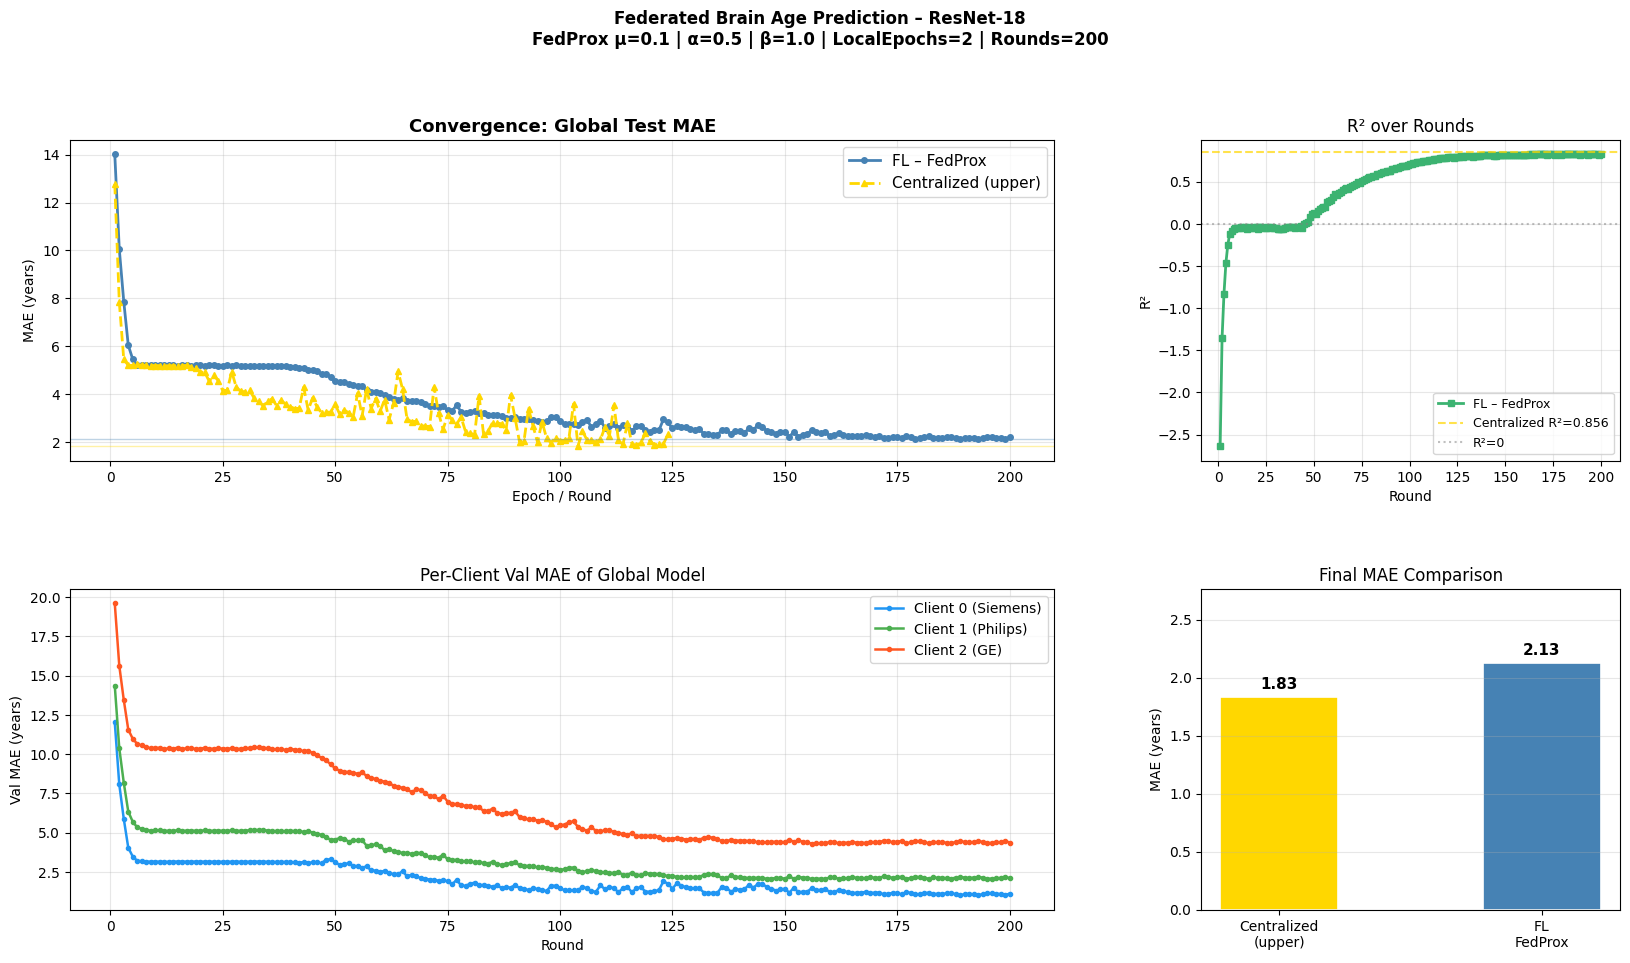

Saved → federated_results.png


In [11]:
rounds = fl_history["round"]
colors = ['#2196F3', '#4CAF50', '#FF5722']

fig = plt.figure(figsize=(20, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

ax1 = fig.add_subplot(gs[0, :2])
ax1.plot(rounds, fl_history["global_mae"],
         'o-', color='steelblue', lw=2, ms=4, label='FL – FedProx')
ax1.plot(central_history["epoch"], central_history["mae"],
         '^--', color='gold', lw=2, ms=4, label='Centralized (upper)')
ax1.axhline(central_mae, color='gold',      alpha=0.35, lw=1)
ax1.axhline(fl_mae,      color='steelblue', alpha=0.35, lw=1)
ax1.set_title("Convergence: Global Test MAE", fontsize=13, fontweight='bold')
ax1.set_xlabel("Epoch / Round")
ax1.set_ylabel("MAE (years)")
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

ax2 = fig.add_subplot(gs[0, 2])
ax2.plot(rounds, fl_history["global_r2"],
         's-', color='mediumseagreen', lw=2, ms=4, label='FL – FedProx')
ax2.axhline(central_r2, color='gold', ls='--', alpha=0.7,
            label=f'Centralized R²={central_r2:.3f}')
ax2.axhline(0, color='gray', ls=':', alpha=0.5, label='R²=0')
ax2.set_title("R² over Rounds", fontsize=12)
ax2.set_xlabel("Round")
ax2.set_ylabel("R²")
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

ax3 = fig.add_subplot(gs[1, :2])
for cid in range(NUM_CLIENTS):
    ax3.plot(rounds, fl_history["per_client_mae"][cid],
             'o-', color=colors[cid], lw=1.8, ms=3,
             label=f'Client {cid} ({SCANNER_NAMES[cid]})')
ax3.set_title("Per-Client Val MAE of Global Model", fontsize=12)
ax3.set_xlabel("Round")
ax3.set_ylabel("Val MAE (years)")
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3)

ax4   = fig.add_subplot(gs[1, 2])
names = ['Centralized\n(upper)', 'FL\nFedProx']
maes  = [central_mae, fl_mae]
bars  = ax4.bar(names, maes, color=['gold', 'steelblue'],
                edgecolor='white', lw=1.2, width=0.45)
ax4.bar_label(bars, fmt='%.2f', padding=4, fontsize=11, fontweight='bold')
ax4.set_title("Final MAE Comparison", fontsize=12)
ax4.set_ylabel("MAE (years)")
ax4.set_ylim(0, max(maes) * 1.3)
ax4.grid(True, axis='y', alpha=0.3)

fig.suptitle(
    f"Federated Brain Age Prediction – ResNet-18\n"
    f"FedProx μ={FEDPROX_MU} | α={FL_ALPHA} | β={FL_BETA} | "
    f"LocalEpochs={LOCAL_EPOCHS} | Rounds={NUM_ROUNDS}",
    fontsize=12, fontweight='bold', y=1.01
)
plt.savefig("federated_results.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved → federated_results.png")